In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))  # Go up one directory

from llm_provider import LLM_provider
llm=LLM_provider()
model=llm.get_llm()
model.invoke("hi")



AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 5, 'engine_ttft_ms': 33, 'engine_ttlt_ms': 84, 'pre_inference_ms': 89, 'service_tbt_ms': 5, 'service_ttft_ms': 876, 'service_ttlt_ms': 921, 'total_duration_ms': 840, 'user_visible_ttft_ms': 786}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_7a7fd0eb44', 'id': 'chatcmpl-DixlrBGJsYbAF4kvU8ciWOT8VDaHn', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun

In [3]:
search_tool=DuckDuckGoSearchRun()
search_tool.invoke("what is the cpaital for frnace")

'1 week ago -Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan population of 13.2 million as of January 2026. Located on the river Seine in the centre of the Île-de-France region, it is the largest ... 2 days ago -Metropolitan Francewas settled during the Iron Age by Celtic tribes known as Gauls before Rome annexed the area in 51 BC, leading to a distinct Gallo-Roman culture. In the Early Middle Ages, the Franks formed the kingdom of Francia, which became the heartland of the Carolingian Empire. March 10, 2026 -This is a chronological list of capitals of France. The capital of France has beenParissince its liberation in 1944. 6 days ago -\'Island of France\') is the most ... Paris, it is located in the north-central part of the country and often called theParis Region(French: Région parisienne,... December 3, 2025 -The correct answer isParis, which is the capital and largest city o

In [4]:
my_code="""
x=6
y=x**2
print(y)
"""

In [5]:
from langchain_experimental.utilities import PythonREPL

In [6]:
repl=PythonREPL()
repl.run(my_code)

Python REPL can execute arbitrary code. Use with caution.


'36\n'

In [7]:
from typing import Annotated

## Note: Annotated
`Annotated[type, metadata]` attaches extra info to a type hint. Python ignores the metadata but frameworks read it.

Two uses:
1. **Description** → `Annotated[str, "description for LLM"]` — tells LLM what to pass
2. **Reducer function** → `Annotated[list, add_messages]` — tells LangGraph HOW to update the field

```python
# In @tool — second arg is a description sent to the LLM as part of tool schema
code: Annotated[str, "the python code to execute"]

# In State — second arg is a reducer function
messages: Annotated[list[AnyMessage], add_messages]
```

In [8]:
from langchain_core.tools import tool

In [9]:
@tool
def python_repl_tool(code:Annotated[str,"the python code to execute to genrate your chart"]):
    """
    Use this to execute python code and do math. If you want to see the output of a value, 
    you should print it out with `print(...)`. This is visible to the user.
    """
    
    try :
        result=repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
C:\Users\User\AppData\Local\Temp\ipykernel_26964\1963195456.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\User\AppData\Local\Temp\ipykernel_26964\1963195456.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


## Note: @tool + Annotated + BaseException

**Annotated here** → the second arg `"the python code to execute..."` is a description. LangChain reads it and includes it in the tool schema sent to the LLM — so the LLM knows exactly what to pass for `code`.

**BaseException vs Exception:**
- `Exception` catches normal errors (ValueError, TypeError, ZeroDivisionError...)
- `BaseException` catches EVERYTHING — including SystemExit, KeyboardInterrupt
- We use `BaseException` here because the LLM generates arbitrary code. We never want it to crash the whole agent — always catch it and return the error back to the LLM so it can fix itself.

**`as e` + `repr(e)`** → captures the error as a readable string like `ZeroDivisionError('division by zero')` — this gets sent back to the LLM so it understands what went wrong and can retry.

In [10]:
python_repl_tool.invoke(my_code)

'Successfully executed:\n\\`\\`\\`python\n\nx=6\ny=x**2\nprint(y)\n\n\\`\\`\\`\nStdout: 36\n'

In [11]:
members=["researcher","coder"]

In [12]:
from typing_extensions import TypedDict
from typing import Literal

In [13]:
class Router(TypedDict):
    next: Literal['researcher','coder','FINISH']

## Note: TypedDict + Literal + Router

**TypedDict** → defines a dict with fixed keys and types. `next` is the only valid key here — it's not a variable or attribute, it's called a **field** (the dict key defined upfront).

**Literal** → restricts values to specific options only. Think of it like a dropdown — the LLM can ONLY return one of these exact strings, nothing else.

**Why a class instead of a plain dict?**
- Reusable across multiple nodes
- `llm.with_structured_output(Router)` needs a class to generate a JSON schema from — a plain dict has no schema
- Self-documenting: anyone reading knows exactly what values are valid

**Router is temporary** — it's just a mold that shapes the LLM's response. Once the value is extracted and written to State, the Router object is thrown away.

In [14]:
from langgraph.graph import MessagesState,StateGraph,START, END

In [15]:
class State(MessagesState):
    next:str

## Note: State — The Whiteboard

Think of `State` as a **shared whiteboard** that every node (supervisor, researcher, coder) can read from and write to.

```
WHITEBOARD (State):
┌──────────────────────────────────────────┐
│ messages: [HumanMessage("research AI")]  │  ← grows via add_messages reducer
│ next: "researcher"                       │  ← set by supervisor after LLM decides
└──────────────────────────────────────────┘
```

- `messages` comes from `MessagesState` — it uses `add_messages` reducer, so messages are **appended not overwritten** each time an agent responds
- `next` starts empty → gets filled by the supervisor LLM → LangGraph uses it to route to the right node

**Router vs State:**
- `Router` = what the LLM outputs (temporary, one field, just a decision slip)
- `State` = the full shared memory of the entire graph run (grows over time)

In [16]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [17]:

# state = {"messages": ["hi"], "next": ""}
# messages = [{"role": "system", "content": system_prompt},] + state["messages"]
# #                              ↑ empty at start

# # LLM reads messages and decides
# response = model.with_structured_output(Router).invoke(messages)
# # response = {"next": "researcher"}

# # NOW state gets updated
# state["next"] = "researcher"
# #                ↑ only gets value AFTER LLM decides


## Note: How state.next gets its value

`state["next"]` is always empty at the start — it only gets a value AFTER the LLM decides.

Flow:
```
state["messages"] + system_prompt  →  sent to LLM
                                           ↓
                              LLM returns Router {"next": "researcher"}
                                           ↓
                              state["next"] = "researcher"   ← written to whiteboard
                                           ↓
                              LangGraph reads state["next"] → routes to researcher node
```

- `messages` = INPUT to LLM (conversation history + instructions)
- `Router` = OUTPUT from LLM (the decision)
- Router never goes INTO messages — it's always the END result of the LLM reading messages

In [18]:
from langgraph.types import Command

In [22]:
def supervisor_agent(state:State)->Command[Literal['researcher','coder','__end__']]:
    messages=[{"role":"system","content":system_prompt}]+state["messages"]
    llm_with_structured_output=model.with_structured_output(Router)
    response=llm_with_structured_output.invoke(messages)
    goto=response["next"]
    
    if goto=="FININSH":
        goto=END
    
    return Command(goto=goto,update={"next":goto})

## Note: Command — update state AND route in one shot

`Command` lets a node do two things at once:
- `update` → write to the whiteboard (State)
- `goto` → directly jump to a node (no need for conditional edges)

```python
return Command(goto=goto, update={"next": goto})
#                  ↑                    ↑
#     route to this node       write this to State
```

**Command vs returning a plain dict:**
| | `return {"next": "researcher"}` | `return Command(...)` |
|---|---|---|
| Updates state | ✅ | ✅ |
| Controls routing | ❌ LangGraph decides via edges | ✅ you decide directly |
| Go to multiple nodes | ❌ | ✅ `goto=["researcher", "coder"]` |
| Cross-graph routing | ❌ | ✅ `Command.PARENT` |

**Why update state if goto already routes?**
`goto` handles routing, but `update` keeps the whiteboard in sync so other nodes can read `state["next"]` and know where the supervisor sent the flow.

In [21]:
from langgraph.prebuilt import create_react_agent

In [23]:
from langchain_core.messages import AIMessage,HumanMessage

In [25]:
def research_agent(state:State)->Command[Literal["supervisor"]]:
    research_agent=create_react_agent(model,tools=[search_tool],prompt="You are a researcher. DO NOT do any math.")
    result=research_agent.invoke(state)
    return Command(goto="supervisor",update={
        "messages":[HumanMessage(content=result["messages"][-1].content, name="researcher")]
    })


In [26]:
def coder_agent(state:State)->Command[Literal["supervisor"]]:
    coder_agent=create_react_agent(model,tools=[python_repl_tool],prompt="Yoa are a coder.Do not do any research")
    result=coder_agent.invoke(state)
    return Command(goto="supervisor",update={
        "messages":[HumanMessage(content=result["messages"][-1].content,name="researcher")]
    })


In [27]:
graph=StateGraph(State)

In [28]:
graph.add_node("supervisor", supervisor_agent)

In [29]:
graph.add_node("researcher", research_agent)

In [30]:
graph.add_node("coder", coder_agent)

In [31]:
graph.add_edge(START, "supervisor")

In [32]:
app=graph.compile()

In [33]:
from IPython.display import display,Image

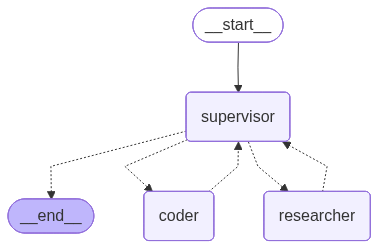

In [34]:
display(Image(app.get_graph().draw_mermaid_png()))

In [37]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]},subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

((), {'supervisor': {'next': 'coder'}})
**********BELOW IS MY STATE***************


C:\Users\User\AppData\Local\Temp\ipykernel_26964\883875974.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  coder_agent=create_react_agent(model,tools=[python_repl_tool],prompt="Yoa are a coder.Do not do any research")


(('coder:7b02601c-e059-7019-1197-603e588a1e0c',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 108, 'total_tokens': 132, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 6, 'engine_ttft_ms': 36, 'engine_ttlt_ms': 185, 'pre_inference_ms': 119, 'service_tbt_ms': 6, 'service_ttft_ms': 638, 'service_ttlt_ms': 787, 'total_duration_ms': 671, 'user_visible_ttft_ms': 519}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_f84d8a14a9', 'id': 'chatcmpl-Dj36tsACQv0u6N3ixyWnXUcq8trss', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detec

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel branch:to:FINISH, ignoring it.


((), {'supervisor': {'next': 'FINISH'}})
**********BELOW IS MY STATE***************


In [ ]:
#  {'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 108, 'total_tokens': 132, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 6, 'engine_ttft_ms': 36, 'engine_ttlt_ms': 185, 'pre_inference_ms': 119, 'service_tbt_ms': 6, 'service_ttft_ms': 638, 'service_ttlt_ms': 787, 'total_duration_ms': 671, 'user_visible_ttft_ms': 519}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_f84d8a14a9', 'id': 'chatcmpl-Dj36tsACQv0u6N3ixyWnXUcq8trss', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'tool_calls', 'logprobs': None, 'content_filter_results': {}}, id='lc_run--019e5a28-da0d-74e2-9836-f01755ae40f0-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_n5MIePpXJbuQSOE62J6gmTFZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 108, 'output_tokens': 24, 'total_tokens': 132, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}})